# Candidate Space Discussion

This notebook is the first code-facing walkthrough of the single-user model. It fixes one radio scenario and one user demand, runs the single-user search, and then inspects the feasible candidate set that comes back.

The main point is simple. Even when the scenario and user case are fixed, the solver can still admit many different PHY allocations. The notebook therefore does not try to present one universal answer. Instead, it shows how the candidate space is built, what a feasible result table looks like, and how one selected row can be read as one concrete time-frequency-layer allocation.


## 1. Fixed scenario and one explicit user case

The notebook starts from the shared single-user study setup. That setup already fixes the common radio assumptions used in this part of the repo, including the carrier setting, bandwidth options, slot window, admitted layer counts, MCS sweep, PRB step, and PA catalog.

One explicit user case is then pinned down by two inputs: distance and required average downlink rate. Once those are fixed, the code can build one scenario object, prepare the corresponding deployment, and define the discrete search space explored in the later cells.


### Terms used in this notebook

A few terms appear often in the tables and plots:

- **PA**: the power amplifier model used for the candidate.
- **BWP**: the bandwidth part that defines the available frequency span for scheduling.
- **PRB**: the number of scheduled physical resource blocks inside that bandwidth part.
- **MCS**: the modulation and coding choice used to map resources to throughput and required SINR.
- **Layers**: the number of spatial layers used by the candidate.
- **Candidate**: one discrete tuple of the form `(PA, BWP, n_PRB, n_slots_on, layers, MCS)`.
- **Feasible candidate**: a candidate that passes the model checks and meets the required rate.

The notebook moves from the prepared scenario, to raw candidate tuples, to the final feasible table for that one user case.


In [1]:
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
%matplotlib inline
from IPython.display import display

repo_root = next(
    (
        candidate
        for candidate in (Path.cwd(), Path.cwd().parent)
        if (candidate / "src").exists() and (candidate / "helpers").exists()
    ),
    next(
        (candidate for candidate in (Path.cwd(), Path.cwd().parent) if (candidate / "src").exists()),
        Path.cwd(),
    ),
)

sys.path.insert(0, str(repo_root.resolve()))

from helpers.candidate_space_helpers import (
    plot_candidate_allocation,
    plot_feasible_candidate_cloud,
    plot_pa_operating_curves,
    prepare_repo_paths,
)

DOC_IMG_DIR, _ = prepare_repo_paths(repo_root)

from single_user_parameter_space import (
    build_single_user_pa_curve_table,
    build_single_user_scenario,
    preview_single_user_candidates,
    run_single_user_scenario,
    summarize_single_user_scenario,
)


In [2]:
# Fix one explicit user case and run the cleaned single-user API.
user_case = {
    "distance_m": 300.0,
    "required_rate_bps": 5e6,
}

scenario = build_single_user_scenario(
    distance_m=float(user_case["distance_m"]),
    required_rate_bps=float(user_case["required_rate_bps"]),
)
search_result = run_single_user_scenario(scenario)
search_views = summarize_single_user_scenario(scenario)

candidate_space_view = search_views["candidate_space_view"].copy()
example_candidate_view = search_views["example_candidate_view"].copy()
pa_characteristics = search_views["pa_characteristics"].copy()

candidate_preview = preview_single_user_candidates(scenario, limit=5).copy()
candidate_table = search_result.copy().reset_index(drop=True)
feasible_table = candidate_table.copy()
pa_label_by_id = {
    int(pa_id): str(pa.scenario_label)
    for pa_id, pa in enumerate(scenario.context.pa_catalog)
}

if feasible_table.empty:
    raise ValueError("The chosen user case produced no feasible candidates.")

# Keep one deterministic example row so the later table and 3D view stay stable.
best_feasible_row = (
    feasible_table.sort_values(
        [
            "p_dc_avg_total_w",
            "bandwidth_hz",
            "n_prb",
            "n_slots_on",
            "layers",
            "mcs",
            "pa_id",
            "bwp_idx",
        ]
    )
    .reset_index(drop=True)
    .iloc[0]
)
best_feasible_label = pa_label_by_id[int(best_feasible_row["pa_id"])]

total_slots = int(example_candidate_view.loc[0, "available_slots"])
total_prbs = int(example_candidate_view.loc[0, "available_prbs"])
max_layers = int(example_candidate_view.loc[0, "available_layers"])


## 2. Prepared case, search-space views, and raw candidate preview

The next outputs make the prepared case concrete.

The first tables summarize the search space available for this user case and the PA options admitted inside it. These are not yet the final feasible results. They describe the bounds of the search.

The preview table shown after them then lists a few raw candidate tuples produced from that setup. This preview is useful because it makes the search variables visible before feasibility filtering is applied. At this stage, the rows are examples from the discrete candidate construction, not yet the final set of admissible solutions.


In [3]:
display(candidate_space_view)


,pa_labels,bandwidth_options_hz,max_prbs_by_bwp,slot_domain,layer_domain,mcs_domain,prb_step,raw_candidate_count_per_pa,raw_candidate_count_total,raw_candidate_count_across_scenarios
0,"(8W PA, 4W PA)","(50000000.0, 100000000.0)","((8W PA, 1, 138), (8W PA, 0, 277), (4W PA, 1, ...","(1, 20)","(1, 4)","(0, 28)",5,"((8W PA, 194880), (4W PA, 194880))",389760,389760


In [4]:
display(candidate_preview)


,pa_id,bwp_idx,n_prb,n_slots_on,layers,mcs
0,0,0,1,1,1,0
1,0,0,1,1,1,1
2,0,0,1,1,1,2
3,0,0,1,1,1,3
4,0,0,1,1,1,4


## 2.5 PA operating-point view

The table below lists the PA operating points used by the scenario summary. The plot after it turns those operating points into three checks: gain, efficiency, and DC input power as the average output power increases.

This is still a search-space view. It helps show what the admitted PA models look like before the feasible candidate cloud is discussed.


### Idle-power point

An idle-power row was added for each PA to represent the quiescent DC consumption when the PA is biased on but not delivering RF output. For this point, the RF quantities are set to zero (`Pin_W = 0`, `Pout_W = 0`, `PAE_percent = 0`), and only the DC input power remains.

For the QPA9942, the idle power is estimated from the datasheet quiescent current:
$$
P_{\mathrm{idle}} = V_{CC} I_Q = 5\,\mathrm{V} \times 84.3\,\mathrm{mA} \approx 0.4215\,\mathrm{W}.
$$

For the Bae et al. GaN Doherty PA, the idle power is estimated from the reported quiescent currents of the driver and carrier stages:
$$
P_{\mathrm{idle}} = V_{DD}(I_{Q,\mathrm{driver}} + I_{Q,\mathrm{carrier}})
= 48\,\mathrm{V} \times (30\,\mathrm{mA} + 50\,\mathrm{mA})
= 3.84\,\mathrm{W}.
$$

This added row provides a baseline DC operating point for comparison against the active transmit region.


In [5]:
display(pa_characteristics)

,pa_id,scenario_label,pa_name,source_csv,n_curve_points,p_max_w,p_idle_w,eta_max,g_pa_eff_linear,g_pa_eff_db,kappa_distortion,backoff_db
0,0,8W PA,Bae et al. NR,C:\Users\henry\Documents\Masters Thesis\code\P...,64,7.928899,3.8400,0.418165,1817.545759,32.594854,0.08,6.0
1,1,4W PA,QPA9942,C:\Users\henry\Documents\Masters Thesis\code\P...,64,1.784671,0.4215,0.352236,935.848316,29.712055,0.08,6.0


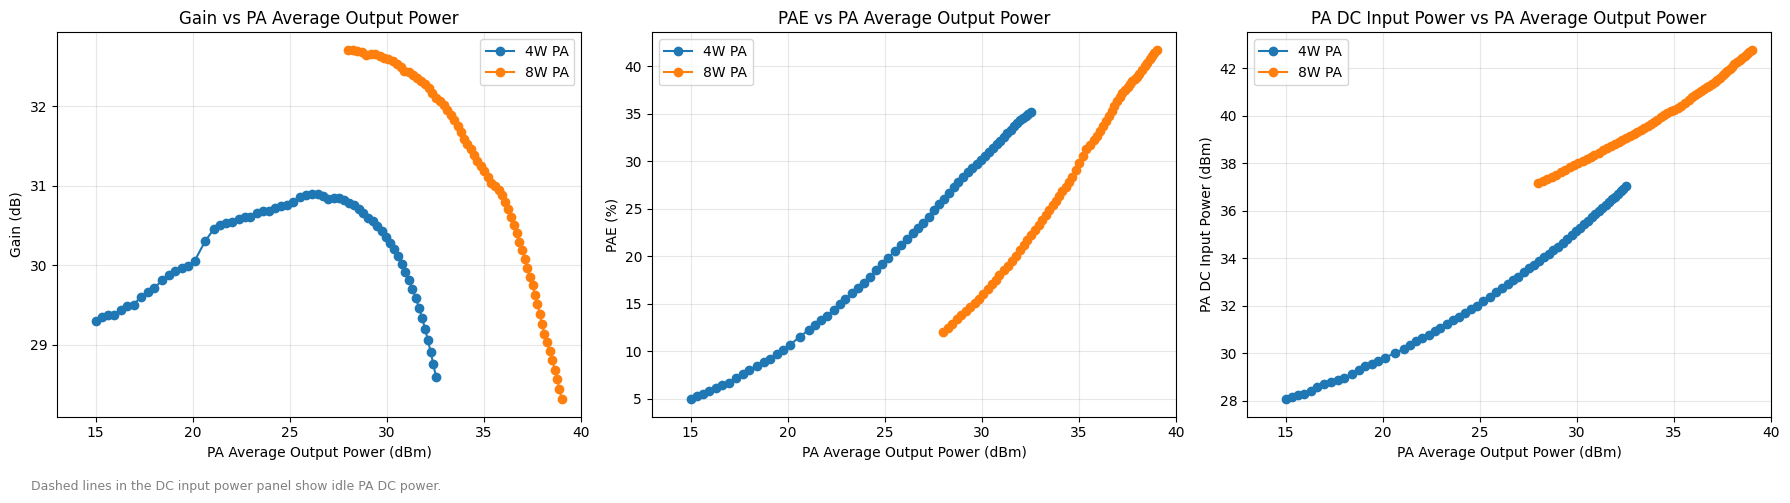

(<Figure size 1800x500 with 3 Axes>,
 array([<Axes: title={'center': 'Gain vs PA Average Output Power'}, xlabel='PA Average Output Power (dBm)', ylabel='Gain (dB)'>,
        <Axes: title={'center': 'PAE vs PA Average Output Power'}, xlabel='PA Average Output Power (dBm)', ylabel='PAE (%)'>,
        <Axes: title={'center': 'PA DC Input Power vs PA Average Output Power'}, xlabel='PA Average Output Power (dBm)', ylabel='PA DC Input Power (dBm)'>],
       dtype=object))

In [6]:
pa_curve_table = build_single_user_pa_curve_table(scenario)
plot_pa_operating_curves(pa_curve_table)


## 3. Feasible candidate cloud across PA choices

After the raw tuples have been evaluated, the solver returns the feasible candidate table for this one user case. Each remaining row is one allocation that satisfies the required rate and passes the model checks.

The scatter plot below makes the main point of the notebook visible. A single user request does not collapse into one forced PHY configuration. Even with a fixed scenario, the solver can still admit a cloud of structurally different feasible rows across bandwidth, PRBs, active slots, layers, MCS, and PA choice.

The highlighted row is only one deterministic example taken from that cloud. It is marked so that the later interpretation step can point to one concrete allocation.


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\single_user_resource_allocation_feasible_points.png


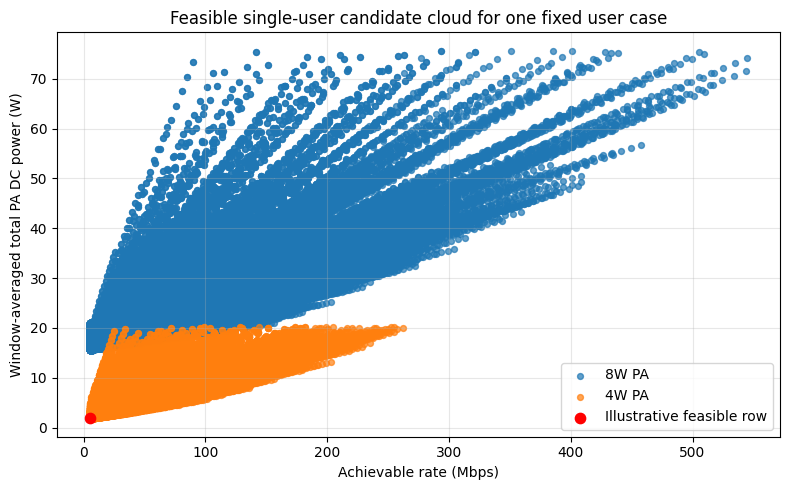

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Feasible single-user candidate cloud for one fixed user case'}, xlabel='Achievable rate (Mbps)', ylabel='Window-averaged total PA DC power (W)'>)

In [7]:
plot_feasible_candidate_cloud(
    feasible_table=feasible_table,
    pa_label_by_id=pa_label_by_id,
    best_feasible_row=best_feasible_row,
    doc_img_dir=DOC_IMG_DIR,
    export_filename="single_user_resource_allocation_feasible_points.png",
)


## 4. Reading one feasible allocation

To make the feasible set easier to interpret, one deterministic example row is selected: the feasible candidate with the lowest window-averaged total PA DC power after a stable ordering. This row is not treated as the only meaningful solution. It is simply one reproducible example taken from the larger feasible cloud.

The table first reports the exact row that was selected. The 3D block below then reads that row along three axes:

- `n_slots_on` gives the occupied time extent inside the fixed slot window,
- `n_prb` gives the occupied frequency extent inside the chosen BWP,
- `layers` gives the occupied spatial extent.

The 3D block should therefore be read as a compact interpretation aid for one feasible row. It shows how one candidate occupies part of the available time-frequency-layer envelope for the prepared case.


In [8]:
display(example_candidate_view)

,scenario_label,pa_name,bandwidth_hz,bwp_idx,allocated_prbs,available_prbs,allocated_slots,available_slots,allocated_layers,available_layers,mcs,rate_ach_bps,window_avg_total_pa_dc_w
0,4W PA,QPA9942,100000000.0,0,266,277,4,20,1,4,3,5007098.88,1.863291


Saved figure to c:\Users\henry\Documents\Masters Thesis\code\img\single_user_resource_allocation_candidate.png


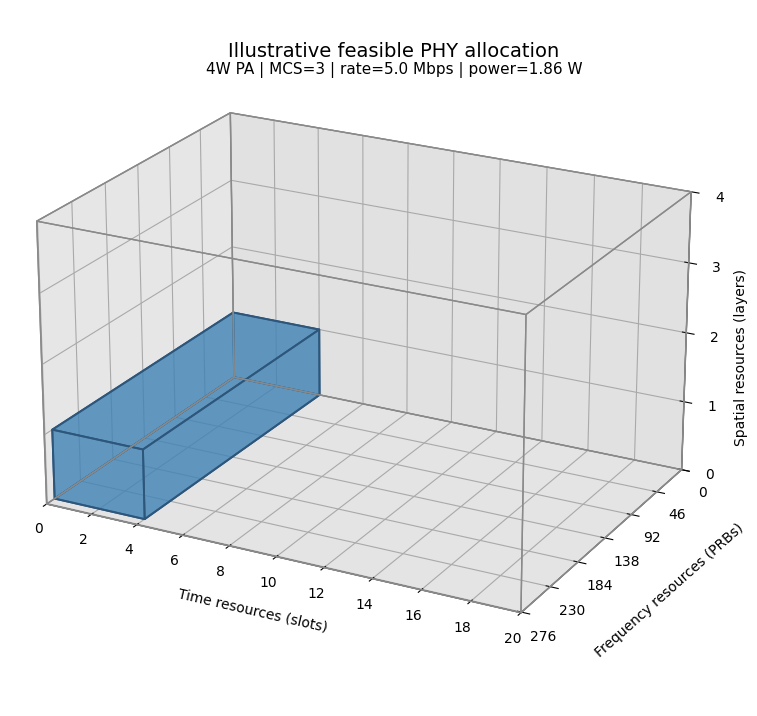

(<Figure size 1200x800 with 1 Axes>,
 <Axes3D: xlabel='Time resources (slots)', ylabel='Frequency resources (PRBs)'>)

In [9]:

plot_candidate_allocation(
    total_slots=total_slots,
    total_prbs=total_prbs,
    max_layers=max_layers,
    best_feasible_row=best_feasible_row,
    best_feasible_label=best_feasible_label,
    doc_img_dir=DOC_IMG_DIR,
    export_filename="single_user_resource_allocation_candidate.png",
)


This notebook establishes the starting point for the single-user model at code level: one fixed scenario, one explicit user case, one constructed candidate space, and one resulting feasible cloud.

The next notebook, `single_user_downlink_power_optimization.ipynb`, builds on this result and studies how the preferred feasible solutions change as the user demand changes.
